# Data processing

In [1]:
from dotenv import load_dotenv
import os 
load_dotenv( dotenv_path = "../../.env",override = True)


WANDB_API_KEY = os.getenv("WANDB_KEY_API")

In [2]:
BASE_PATH = 'data/Dataset/'
TRAIN_PATH = BASE_PATH + 'Train/'
VAL_PATH = BASE_PATH + 'Val/'
TEST_PATH = BASE_PATH + 'Test/'

In [3]:
TEST_PATH

'data/Dataset/Test/'

In [4]:
import os
import shutil
from pathlib import Path
from tqdm import tqdm

# Define paths
BASE_PATH = 'data/Dataset/'
TRAIN_PATH = BASE_PATH + 'Train/'
VAL_PATH = BASE_PATH + 'Val/'
MERGED_PATH = BASE_PATH + 'Merged/'  

def merge_datasets(train_dir, val_dir, merged_dir):
  
    os.makedirs(merged_dir, exist_ok=True)
    
    print("Processing training data...")
    for class_name in os.listdir(train_dir):
        class_dir = os.path.join(train_dir, class_name)
        if not os.path.isdir(class_dir):
            continue
            
        merged_class_dir = os.path.join(merged_dir, class_name)
        os.makedirs(merged_class_dir, exist_ok=True)
        
        # Copy all files from train class directory
        files = os.listdir(class_dir)
        for file in tqdm(files, desc=f"Train - {class_name}"):
            src_path = os.path.join(class_dir, file)
            dst_path = os.path.join(merged_class_dir, f"train_{file}")
            shutil.copy2(src_path, dst_path)
    
    # Process validation directory
    print("\nProcessing validation data...")
    for class_name in os.listdir(val_dir):
        class_dir = os.path.join(val_dir, class_name)
        if not os.path.isdir(class_dir):
            continue
            
        # Create class directory in merged folder (if not already created)
        merged_class_dir = os.path.join(merged_dir, class_name)
        os.makedirs(merged_class_dir, exist_ok=True)
        
        # Copy all files from validation class directory
        files = os.listdir(class_dir)
        for file in tqdm(files, desc=f"Val - {class_name}"):
            src_path = os.path.join(class_dir, file)
            dst_path = os.path.join(merged_class_dir, f"val_{file}")
            shutil.copy2(src_path, dst_path)
    
    # Count files in the merged directory
    total_files = 0
    for class_name in os.listdir(merged_dir):
        class_dir = os.path.join(merged_dir, class_name)
        if os.path.isdir(class_dir):
            num_files = len(os.listdir(class_dir))
            total_files += num_files
            print(f"Class '{class_name}': {num_files} images")
    
    print(f"\nTotal merged images: {total_files}")

# Execute the merge operation
# merge_datasets(TRAIN_PATH, VAL_PATH, MERGED_PATH)
# print(f"Data successfully merged into {MERGED_PATH}")

In [5]:
from torchvision import datasets, transforms


train_transform = transforms.Compose([
    transforms.Resize((256, 256)), 
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  
    transforms.RandomHorizontalFlip(p=0.5), 
    transforms.RandomRotation(15),  
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),  
    transforms.RandomApply([transforms.GaussianBlur(3, sigma=(0.1, 2.0))], p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.1) 
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root = MERGED_PATH, transform = train_transform)
val_dataset = datasets.ImageFolder(root = VAL_PATH, transform = val_test_transform)


In [6]:
train_dataset[0]

(tensor([[[-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          ...,
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179]],
 
         [[-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          ...,
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357]],
 
         [[-1.8044, -1.8044, -1.8044,  ..., -1.8044, -1.8044, -1.8044],
          [-1.8044, -1.8044,

In [7]:
train_dataset[0][0].shape

torch.Size([3, 224, 224])

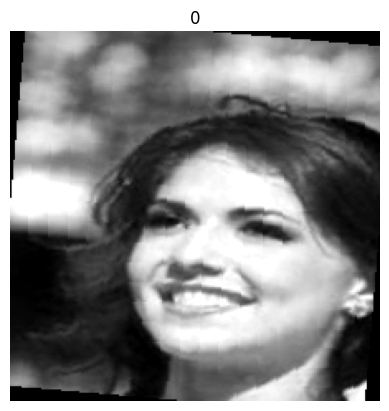

In [8]:
import matplotlib.pyplot as plt



def show_image(datapoint): 

    image, label = datapoint
    plt.imshow(image[0], cmap='gray')
    plt.title(label)
    plt.axis('off')
    plt.show()

show_image(train_dataset[0])

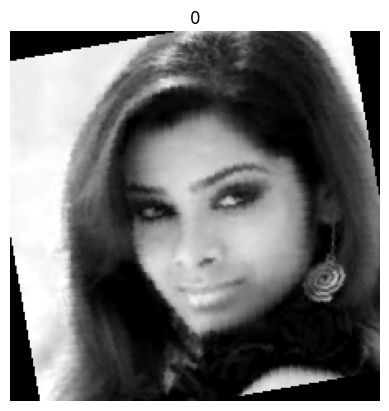

In [9]:
show_image(train_dataset[60])

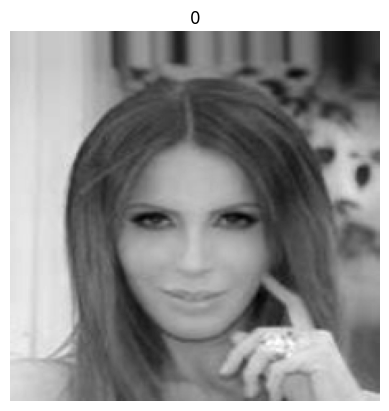

In [10]:
show_image(val_dataset[120])

# Datamodule 

In [11]:
import lightning as pl 
from torch.utils.data import random_split, DataLoader, ConcatDataset 


class GenderDataModule(pl.LightningDataModule):
    def __init__(self, train_dataset, val_dataset, batch_size=32, val_test_ratio = 0.2):
        super().__init__()
        self.train_dataset = train_dataset
        self.val_dataset = val_dataset
        self.batch_size = batch_size
        self.val_test_ratio = val_test_ratio

    def setup(self, stage=None):
        if stage == 'fit' or stage is None:
            self.train_data = ConcatDataset([self.train_dataset, self.val_dataset])
            self.val_data = self.val_dataset
            
        elif stage == 'test':
            test_size = int(len(self.val_dataset) * self.val_test_ratio)
            val_size = len(self.val_dataset) - test_size

            self.val_data, self.test_data = random_split(self.val_dataset, [val_size, test_size])

    def train_dataloader(self):
        return DataLoader(self.train_data, batch_size=self.batch_size, shuffle=True, num_workers=4)

    def val_dataloader(self):
        return DataLoader(self.val_data, batch_size=self.batch_size, num_workers=4)

    def test_dataloader(self):
        return DataLoader(self.test_data, batch_size=self.batch_size, num_workers=4)


# Define model 

In [12]:
import torch.nn as nn 
import torch.optim as optim
import torchvision.models as models


class GenderPretrained: 

    @staticmethod
    def create_resnet18(num_classes=2, pretrained=True):
        model = models.resnet18(pretrained=pretrained)
        num_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        return model

    @staticmethod
    def create_resnet50(num_classes=2, pretrained=True):
        
        model = models.resnet50(pretrained=pretrained)
        num_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        return model
    

    @staticmethod
    def create_efficientnet(num_classes=2, pretrained=True):
        model = models.efficientnet_b0(pretrained=pretrained)
        num_features = model.classifier.in_features
        model.classifier = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        return model

    @staticmethod 
    def create_vision_transformer(num_classes=2, pretrained=True):
        
        model = models.vit_b_16(pretrained=pretrained)
        num_features = model.heads.head.in_features
        model.heads.head = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
        return model


    @staticmethod
    def create_efficientnet_v2(num_classes=2, pretrained=True):

        model = models.efficientnet_v2_s(pretrained=pretrained)
        num_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        return model
    
    @staticmethod
    def create_efficientnet_v2_l(num_classes=2, pretrained=True):

        model = models.efficientnet_v2_l(pretrained=pretrained)
        num_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(num_features, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
        return model

In [13]:
from torchmetrics import Accuracy, F1Score, Precision, Recall


def get_model(model_name: str, num_classes: int = 2, pretrained: bool = True):
    model_map = {
        'resnet18': GenderPretrained.create_resnet18,
        'resnet50': GenderPretrained.create_resnet50,
        'efficientnet': GenderPretrained.create_efficientnet,
        'vision_transformer': GenderPretrained.create_vision_transformer,
        'efficientnet_v2': GenderPretrained.create_efficientnet_v2, 
        'efficientnet_v2_l': GenderPretrained.create_efficientnet_v2_l
    }


    if model_name not in model_map:
        available_models = list(model_map.keys())
        raise ValueError(f"Model {model_name} not recognized. Choose from: {available_models}")
    
    return model_map[model_name](num_classes, pretrained)

    


class GenderModule(pl.LightningModule):
    def __init__(self, model_name: str):
        super().__init__()
        self.model = get_model(model_name)

        self.criterion = nn.CrossEntropyLoss()

        self.train_acc = Accuracy(task = 'multiclass', num_classes=2)
        self.val_acc = Accuracy(task = 'multiclass', num_classes=2)
        self.test_acc = Accuracy(task = 'multiclass', num_classes=2)

        self.val_f1 = F1Score(task = 'multiclass', num_classes=2)
        self.val_precision = Precision(task = 'multiclass', num_classes=2)
        self.val_recall = Recall(task = 'multiclass', num_classes=2)

        self.test_f1 = F1Score(task = 'multiclass', num_classes=2)
        self.test_precision = Precision(task = 'multiclass', num_classes=2)
        self.test_recall = Recall(task = 'multiclass', num_classes=2)
        self.save_hyperparameters()

        

    def forward(self, x):
        return self.model(x)
    


    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        acc = self.train_acc(y_hat, y)
        self.log('train_loss', loss)

        self.log('train_acc', acc, on_step=True, prog_bar=True)
        self.log('train_acc_epoch', self.train_acc, on_epoch=True, prog_bar=True)

        return loss
    

    def validation_step(self, batch, batch_idx):
        x, y = batch 
        y_hat = self(x)
        loss = self.criterion(y_hat, y)

        acc = self.val_acc(y_hat, y)
        f1 = self.val_f1(y_hat, y)
        precision = self.val_precision(y_hat, y)
        recall = self.val_recall(y_hat, y)

        self.log('val_loss', loss, on_step=True, prog_bar=True)
        self.log('val_acc', acc, on_step=True, prog_bar=True)
        self.log('val_f1', f1, on_step=True, prog_bar=True)
        self.log('val_precision', precision, on_step=True, prog_bar=True)
        self.log('val_recall', recall, on_step=True, prog_bar=True)



    def test_step(self, batch, batch_idx):
        x, y = batch 
        y_hat = self(x)
        loss = self.criterion(y_hat, y)

        acc = self.test_acc(y_hat, y)
        f1 = self.test_f1(y_hat, y)
        precision = self.test_precision(y_hat, y)
        recall = self.test_recall(y_hat, y)

        self.log('test_loss', loss, on_step=True, prog_bar=True)
        self.log('test_acc', acc, on_step=True, prog_bar=True)
        self.log('test_f1', f1, on_step=True, prog_bar=True)
        self.log('test_precision', precision, on_step=True, prog_bar=True)
        self.log('test_recall', recall, on_step=True, prog_bar=True)



    def configure_optimizers(self):

        backbone_params = []
        classifier_parames = []

        for name, param in self.model.named_parameters():
            if 'fc' in name or 'classifier' in name or 'head' in name: 
                classifier_parames.append(param)

            else : 
                backbone_params.append(param)




        optimizer = optim.AdamW(
            [
                {'params': backbone_params, 'lr': 1e-5}, 
                {'params': classifier_parames, 'lr': 1e-3}
            ]            
            , lr=1e-4, weight_decay=1e-2)

        scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer, T_0=5, T_mult=2, eta_min=1e-6
        )
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'monitor': 'val_acc'
            }
        }



In [14]:
config_1 = {
    'model_name': 'vision_transformer',
    'batch_size': 64,
    'max_epochs': 15,
    'gpus': 1,
    'num_workers': 4,
    'val_test_ratio': 0.2,
    'precision' : 16, 
    'accumulate_grad_batches' :2
    
}

In [15]:
config_2 = {
    'model_name': 'resnet18',
    'batch_size': 64,
    'max_epochs': 15,
    'gpus': 1,
    'num_workers': 4,
    'val_test_ratio': 0.2,
    'precision' : 16, 
    'accumulate_grad_batches' :2
    
}

In [16]:
config_3 = {
    'model_name': 'efficientnet_v2',
    'batch_size': 64,
    'max_epochs': 15,
    'gpus': 1,
    'num_workers': 4,
    'val_test_ratio': 0.2,
    'precision' : 16, 
    'accumulate_grad_batches' :2
    
}

In [17]:
configs = [config_1, config_2, config_3]

In [19]:
from lightning.pytorch.loggers import WandbLogger
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
import wandb
name = ['vision_transformer', 'resnet18', 'efficientnet_v2']
for config in configs:
      wandb.login(
      key = WANDB_API_KEY
      )
      model_name = config['model_name']
      wandb_logger = WandbLogger(
            name = config['model_name'],
            project = "Gender Classification",
            log_model = False 
      )

      model_checkpoint = ModelCheckpoint(
            dirpath='checkpoints/',
            filename= model_name +  f"-{{epoch}}-{{val_loss:.2f}}",
            monitor='val_loss',
            save_top_k=3,
            mode='min',
            save_weights_only=True
      )

      early_stopping = EarlyStopping(
            monitor='val_loss',
            patience=3,
            verbose=False,
            mode='min'
      )

      trainer = pl.Trainer(
            accelerator = "cuda",
            devices = config['gpus'],
            max_epochs = config['max_epochs'],
            callbacks = [early_stopping, model_checkpoint],
            logger = wandb_logger, 
            precision = config['precision'],
            accumulate_grad_batches = config['accumulate_grad_batches'], 
            gradient_clip_val= 1.0
      )


      model = GenderModule(config['model_name'])
      data_module = GenderDataModule(
      train_dataset=train_dataset,
      val_dataset=val_dataset,
      batch_size=config['batch_size'],
      val_test_ratio=config['val_test_ratio']
      )


      trainer.fit(model, data_module)
      wandb.finish()
      print(f"Training completed for {model_name} model.")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/thviet/.netrc
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


/workspace/thviet/paracrawl/tools/miniconda3/envs/img_env/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /workspace/thviet/trungnnv/AIT3002-image-processing/final/gender_classification/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name           | Type                | Params | Mode 
----------------------------------------------------------------
0  | model          | VisionTransformer   | 86.2 M | train
1  | criterion      | CrossEntropyLoss    | 0      | train
2  | train_acc      | MulticlassAccuracy  | 0      | train
3  | val_acc        | MulticlassAccuracy  | 0      | train
4  | test_acc       | MulticlassAccuracy  | 0      | train
5  | val_f1         | MulticlassF1Score   | 0      | train
6  | val_precision  | MulticlassPrecision | 0      | train
7  | val_recall     | MulticlassRecall    | 0      | train
8  | test_f1        | MulticlassF1Score   | 0      | train
9  | test_precision | Mu

Epoch 14: 100%|██████████| 157/157 [00:51<00:00,  3.03it/s, v_num=nwj2, train_acc=1.000, train_acc_epoch_step=1.000, val_loss_step=0.000204, val_acc_step=1.000, val_f1_step=1.000, val_precision_step=1.000, val_recall_step=1.000, val_loss_epoch=4.44e-5, val_acc_epoch=1.000, val_f1_epoch=1.000, val_precision_epoch=1.000, val_recall_epoch=1.000, train_acc_epoch_epoch=0.997] 

`Trainer.fit` stopped: `max_epochs=15` reached.


Epoch 14: 100%|██████████| 157/157 [00:51<00:00,  3.03it/s, v_num=nwj2, train_acc=1.000, train_acc_epoch_step=1.000, val_loss_step=0.000204, val_acc_step=1.000, val_f1_step=1.000, val_precision_step=1.000, val_recall_step=1.000, val_loss_epoch=4.44e-5, val_acc_epoch=1.000, val_f1_epoch=1.000, val_precision_epoch=1.000, val_recall_epoch=1.000, train_acc_epoch_epoch=0.997]


...

Epoch 14: 100%|██████████| 157/157 [00:43<00:00,  3.61it/s, v_num=2tk5, train_acc=1.000, train_acc_epoch_step=1.000, val_loss_step=4.29e-5, val_acc_step=1.000, val_f1_step=1.000, val_precision_step=1.000, val_recall_step=1.000, val_loss_epoch=9.38e-5, val_acc_epoch=1.000, val_f1_epoch=1.000, val_precision_epoch=1.000, val_recall_epoch=1.000, train_acc_epoch_epoch=0.991]  

`Trainer.fit` stopped: `max_epochs=15` reached.


Epoch 14: 100%|██████████| 157/157 [00:44<00:00,  3.53it/s, v_num=2tk5, train_acc=1.000, train_acc_epoch_step=1.000, val_loss_step=4.29e-5, val_acc_step=1.000, val_f1_step=1.000, val_precision_step=1.000, val_recall_step=1.000, val_loss_epoch=9.38e-5, val_acc_epoch=1.000, val_f1_epoch=1.000, val_precision_epoch=1.000, val_recall_epoch=1.000, train_acc_epoch_epoch=0.991]


epoch,▁▁▁▁▁▁▂▃▃▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇▇▇██
train_acc,▁▃▃▅▃▃▆█▅█▅█▆▅█▆█▆▆████
train_acc_epoch_epoch,▁▅▆▇▇▇▇▇▇▇█████
train_acc_epoch_step,▁▃▃▅▃▃▆█▅█▅█▆▅█▆█▆▆████
train_loss,▇█▅▅▄▅▂▁▄▁▂▁▂▃▁▂▁▃▂▂▁▂▁
trainer/global_step,▁▁▁▁▁▁▁▁▂▁▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▆▂▂▂▂▂▂▂▂▂▂█
val_acc_epoch,▁▆▇████████████
val_acc_step,█▅▁██████▅██████████████████████████████
val_f1_epoch,▁▆▇████████████
val_f1_step,███▁▃████▆██████████████████████████████
val_loss_epoch,█▄▃▂▁▁▁▂▁▁▁▁▁▁▁


Training completed for efficientnet_v2 model.


In [21]:
import torch 
from PIL import Image
from tqdm import tqdm
from pathlib import Path
import os
import pandas as pd
import torch.nn.functional as F

# Define paths for model checkpoints
model_paths = [
    'checkpoints/efficientnet_v2-epoch=14-val_loss=0.00.ckpt',
    'checkpoints/resnet18-epoch=14-val_loss=0.00.ckpt',
    'checkpoints/vision_transformer-epoch=13-val_loss=0.00.ckpt'
]

# Load models
model_list = []
for path in model_paths:
    model = GenderModule.load_from_checkpoint(path)
    model.to('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    model_list.append(model)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

def process_image(img_path):
    img = Image.open(img_path).convert('RGB')
    return val_test_transform(img).unsqueeze(0).to(device)

def get_prediction_with_confidence(model, img):
    with torch.no_grad():
        logits = model(img)
        probabilities = F.softmax(logits, dim=1)
        confidence, predicted_class = torch.max(probabilities, dim=1)
        return predicted_class.item(), confidence.item(), probabilities

def ensemble_predictions(all_probs, all_preds, all_confs, ensemble_method='weighted_avg'):
    """
    Ensemble predictions from multiple models
    
    ensemble_method: 
        - 'weighted_avg': weight each model's prediction by its confidence
        - 'majority_vote': use most common prediction
        - 'max_confidence': use prediction from model with highest confidence
    """
    if len(all_probs) == 1:
        # If only one model, return its prediction
        return all_preds[0], all_probs[0]
    
    if ensemble_method == 'majority_vote':
        # Count votes for each class
        class_votes = {}
        for pred in all_preds:
            if pred not in class_votes:
                class_votes[pred] = 0
            class_votes[pred] += 1
            
        # Find class with most votes
        final_pred = max(class_votes, key=class_votes.get)
        
        # Average probabilities for final prediction
        all_probs_tensor = torch.stack(all_probs)
        avg_probs = torch.mean(all_probs_tensor, dim=0)
        return final_pred, avg_probs
    
    elif ensemble_method == 'max_confidence':
        # Find model with highest confidence
        max_conf_idx = all_confs.index(max(all_confs))
        return all_preds[max_conf_idx], all_probs[max_conf_idx]
    
    else:  # weighted_avg (default)
        # Weight predictions by confidence
        weighted_probs = torch.zeros_like(all_probs[0])
        sum_conf = sum(all_confs)
        
        for prob, conf in zip(all_probs, all_confs):
            weight = conf / sum_conf
            weighted_probs += prob * weight
            
        final_pred = torch.argmax(weighted_probs, dim=1).item()
        return final_pred, weighted_probs

# Function to run predictions on test data
def run_prediction(use_models=None, ensemble_method='weighted_avg', output_filename='gender_predictions.csv'):
    """
    Run predictions on test data
    
    use_models: list of model indices to use (None = use all models)
    ensemble_method: method for ensembling predictions
    output_filename: name of output CSV file
    """
    if use_models is None:
        use_models = list(range(len(model_list)))

    active_models = [model_list[i] for i in use_models]

    test_files = sorted([f for f in os.listdir(TEST_PATH) if f.endswith(('.jpg', '.jpeg', '.png'))])
    results = []
    
    with torch.no_grad():
        for file_name in tqdm(test_files, desc="Processing test images"):
            img_id = Path(file_name).stem
            img_path = os.path.join(TEST_PATH, file_name)
            img = process_image(img_path)
            
            all_preds = []
            all_confs = []
            all_probs = []
            
            for model in active_models:
                pred, confidence, probabilities = get_prediction_with_confidence(model, img)
                all_preds.append(pred)
                all_confs.append(confidence)
                all_probs.append(probabilities)
            
            pred_class, _ = ensemble_predictions(all_probs, all_preds, all_confs, ensemble_method)
            
            # Adjust class labels if needed (0->1 and 1->0 as in original code)
            if pred_class == 0:
                pred_class = 1
            elif pred_class == 1:
                pred_class = 0
                
            results.append({
                "ID": img_id,
                "Label": pred_class
            })
    
    df = pd.DataFrame(results)
    df.to_csv(output_filename, index=False)
    
    print(f"Predictions saved to {output_filename}")
    return df

# Example usage:
# Run with all models using weighted average ensemble
run_prediction(ensemble_method='majority_vote', output_filename='gender_predictions_ensemble.csv')

# Run with just the first model (Vision Transformer)
# run_prediction(use_models=[0], output_filename='gender_predictions_vit.csv')

# Run with just the second model (EfficientNet)
# run_prediction(use_models=[1], output_filename='gender_predictions_efficientnet.csv')

/workspace/thviet/paracrawl/tools/miniconda3/envs/img_env/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/workspace/thviet/paracrawl/tools/miniconda3/envs/img_env/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_V2_S_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/workspace/thviet/paracrawl/tools/miniconda3/envs/img_env/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current 

Predictions saved to gender_predictions_ensemble.csv


,ID,Label
0,000067,0
1,000167,1
2,000480,1
3,000488,1
4,000570,1
...,...,...
995,159239,0
996,159389,1
997,159808,1
998,159946,1
